# M2 v4 — DiT diffusion on fixed-length GPU power traces

Major changes from v3 (which had Pearson r ~ 0.0):

1. **v-prediction** (instead of ε-prediction) — auto-balanced loss across timesteps,
   stable identity-init from zero-init final layer.
2. **Conditioning token prepended to sequence** — gives attention layers direct
   access to SLURM features alongside AdaLN modulation (conservative enrichment).
3. **Min-SNR-γ=5 loss weighting** — focuses learning on mid-range timesteps where
   the real denoising signal lives.
4. **18-dim conditioning** (dropped `dom_sin`/`dom_cos` — single-month leakage risk).
5. **Removed loss_weight upweighting** — adds variance with no learning benefit.
6. **Built-in outlier batch skipping** — prevents the divergence we saw at v3 epoch 21.
7. **Tighter training**: `lr=1.5e-4`, `grad_clip=0.5`, `cond_drop=0.05`, `EMA=0.999`,
   `batch=128`, warmup 2000 steps.

Target hardware: 1× A100 80GB. Expected: ~3 hours for 150 epochs.

Doesn't depend on any v3 checkpoint — trains from scratch.


In [13]:
import builtins
import copy
import gc
import math
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import stats
from scipy.signal import welch
try:
    from dtaidistance import dtw
    HAS_DTW = True
except ImportError:
    HAS_DTW = False
    print("dtaidistance not available — DTW metric will be skipped.")
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings("ignore")

print(f"PyTorch {torch.__version__}  |  CUDA {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"bf16 ok : {torch.cuda.is_bf16_supported()}")


PyTorch 2.10.0+cu128  |  CUDA True
Device  : NVIDIA L40S
VRAM    : 47.7 GB
bf16 ok : True


In [14]:
# ── Paths ────────────────────────────────────────────────────────────────────
SLURM_FEATURES = Path("mit/dataset/slurm_features.parquet")
SEQ_DIR        = Path("mit/dataset/sequences")            # ETL v2 output (.npy per job)
MODEL_OUT      = Path("mit/model_v4")
MMAP_DIR       = MODEL_OUT / "mmap"
IMG_DIR        = Path("mit/images")
MODEL_OUT.mkdir(parents=True, exist_ok=True)
MMAP_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

# ── Feature groups (18-dim cond, dom_* dropped) ──────────────────────────────
CALENDAR_COLS = ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]                                   # 4
CONT_COLS     = ["mem_req_scaled", "nodes_req_log", "cpus_req_scaled",
                 "duration_scaled", "priority_scaled"]                                            # 5
BIN_COLS      = ["mem_unlimited", "nodes_req_is_one",
                 "ptier_0", "ptier_1", "ptier_2",
                 "type_batch", "type_interactive", "type_map", "type_other"]                      # 9
COND_COLS     = CALENDAR_COLS + CONT_COLS + BIN_COLS                                              # 18
VARIANT_COLS  = ["type_batch", "type_interactive", "type_map", "type_other",
                 "nodes_req_is_one"]
EXTRA_COLS    = ["job_id", "nodes_req", "duration_sec"]

# ── Constants (tied to ETL v2) ───────────────────────────────────────────────
L          = 16384
W_PER_NODE = 620.0

# ── Model / training config ──────────────────────────────────────────────────
CFG = {
    "L"            : L,
    "cond_dim"     : len(COND_COLS),       # 18

    # DiT backbone (same shape as v3, plus 1 prepended cond_token at runtime)
    "patch_size"   : 32,
    "d_model"      : 384,
    "n_heads"      : 6,
    "n_layers"     : 12,
    "mlp_ratio"    : 4,
    "dropout"      : 0.0,

    # Diffusion (v-prediction)
    "T"            : 1000,
    "min_snr_gamma": 5.0,                  # Min-SNR-gamma loss weighting
    "ddim_steps"   : 50,

    # Training
    "batch_size"   : 128,                  # A100 80GB target
    "grad_accum"   : 1,
    "lr"           : 1.5e-4,               # lower than v3's 2e-4 for stability
    "weight_decay" : 0.01,
    "epochs"       : 150,
    "grad_clip"    : 0.5,                  # tighter than v3's 1.0
    "warmup_steps" : 2000,                 # longer warmup
    "ema_decay"    : 0.999,                # faster catch-up than v3's 0.9999
    "cond_drop_prob"      : 0.05,          # half of v3
    "cfg_scale"           : 1.5,
    "outlier_loss_thresh" : 5.0,           # per-sample loss threshold
    "max_skip_streak"     : 20,            # abort if too many skipped batches

    # Dataloader
    "num_workers" : builtins.max(1, os.cpu_count() - 2),
    "prefetch"    : 4,

    # Validation / early stop
    "val_every"   : 2,
    "val_batches" : 200,
    "patience"    : 20,                    # more lenient than v3 (since v-pred trains slower early)

    # Outputs
    "save_path"   : str(MODEL_OUT / "best_model.pt"),
    "results_csv" : str(MODEL_OUT / "test_evaluation_results.csv"),
    "samples_png" : str(MODEL_OUT / "test_trace_samples.png"),
}
assert CFG["L"] % CFG["patch_size"] == 0
assert CFG["d_model"] % CFG["n_heads"] == 0

N_TOKENS = CFG["L"] // CFG["patch_size"]
print(f"Sequence length : {CFG['L']:,}  (normalized [-1, 1])")
print(f"Tokens          : {N_TOKENS:,}  (+ 1 cond_token = {N_TOKENS+1})")
print(f"d_model / heads : {CFG['d_model']} / {CFG['n_heads']}")
print(f"Layers          : {CFG['n_layers']}")
print(f"Batch           : {CFG['batch_size']}")
print(f"Cond dim        : {CFG['cond_dim']}  ({len(CALENDAR_COLS)} cal + "
      f"{len(CONT_COLS)} cont + {len(BIN_COLS)} bin)")


Sequence length : 16,384  (normalized [-1, 1])
Tokens          : 512  (+ 1 cond_token = 513)
d_model / heads : 384 / 6
Layers          : 12
Batch           : 128
Cond dim        : 18  (4 cal + 5 cont + 9 bin)


## 1. Load SLURM features & build job index

Filter to jobs that have a normalized power array on disk, store the row index
into the (yet-to-build) memory-mapped power array.


In [15]:
assert SLURM_FEATURES.exists(), f"Missing {SLURM_FEATURES}"
slurm_df = pd.read_parquet(SLURM_FEATURES)
print(f"SLURM features : {len(slurm_df):,} rows, columns: {len(slurm_df.columns)}")

required = set(COND_COLS) | set(EXTRA_COLS)
missing  = required - set(slurm_df.columns)
assert not missing, f"slurm_features.parquet missing required columns: {missing}"

# Filter to job_ids that have a normalized .npy on disk
on_disk = {p.stem for p in SEQ_DIR.glob("*.npy")}
print(f"Sequences on disk: {len(on_disk):,}")

slurm_df["job_id"] = slurm_df["job_id"].astype(str)
mask = slurm_df["job_id"].isin(on_disk)
meta_df = slurm_df.loc[mask, list(required)].reset_index(drop=True)
print(f"Joined          : {len(meta_df):,} jobs")

# Drop any rows with NaN/Inf in the feature columns we use
mask2 = np.isfinite(meta_df[COND_COLS].to_numpy()).all(axis=1)
meta_df = meta_df.loc[mask2].reset_index(drop=True)

# Sanity: nodes_req >= 1, duration_sec > 0
mask3 = (meta_df["nodes_req"] >= 1) & (meta_df["duration_sec"] > 0)
meta_df = meta_df.loc[mask3].reset_index(drop=True)
print(f"After validation: {len(meta_df):,} jobs (clean meta + on disk)")


SLURM features : 98,174 rows, columns: 24
Sequences on disk: 98,171
Joined          : 98,171 jobs
After validation: 98,171 jobs (clean meta + on disk)


## 2. Memory-mapped power array

Build (or load) a single contiguous (N, L) float32 array on disk that we
mmap-read during training. ~6.4 GB for 98k × 16384 × 4 bytes.


In [16]:
MMAP_POWER = MMAP_DIR / "power.npy"       # (N, L) float32 in [-1, 1]
MMAP_INDEX = MMAP_DIR / "job_id.npy"      # (N,)    str job_ids in row order

def build_mmap(meta_df, mmap_power, mmap_index, L):
    if mmap_power.exists() and mmap_index.exists():
        # Verify alignment
        idx_arr = np.load(mmap_index, allow_pickle=True)
        if len(idx_arr) == len(meta_df) and (idx_arr == meta_df["job_id"].values).all():
            print(f"Memmap already exists and matches: {mmap_power} ({mmap_power.stat().st_size/1e9:.2f} GB)")
            return
        print("Existing memmap doesn't match current meta_df — rebuilding.")

    print(f"Building memmap: {len(meta_df):,} jobs x {L} = "
          f"{len(meta_df) * L * 4 / 1e9:.2f} GB")
    arr = np.lib.format.open_memmap(mmap_power, mode="w+", dtype=np.float32,
                                     shape=(len(meta_df), L))
    t0 = time.time()
    for i, jid in enumerate(meta_df["job_id"].values):
        z = np.load(SEQ_DIR / f"{jid}.npy")
        if z.shape[0] != L:
            raise ValueError(f"{jid}: expected ({L},), got {z.shape}")
        arr[i] = z
        if (i + 1) % 5000 == 0:
            print(f"  {i+1:,}/{len(meta_df):,}  ({(i+1)/(time.time()-t0):.0f} jobs/s)")
    arr.flush()
    np.save(mmap_index, meta_df["job_id"].astype(str).values, allow_pickle=True)
    print(f"  Built in {(time.time()-t0)/60:.1f} min")

build_mmap(meta_df, MMAP_POWER, MMAP_INDEX, L)
power_mmap = np.load(MMAP_POWER, mmap_mode="r")
print(f"Memmap shape: {power_mmap.shape}, dtype: {power_mmap.dtype}")


Memmap already exists and matches: mit/model_v4/mmap/power.npy (6.43 GB)
Memmap shape: (98171, 16384), dtype: float32


## 3. Variant-stratified split + Dataset

10% test (touched only at inference), 10% val, 80% train. Variant-stratified
on (job_type, single_node_flag) to keep all variants represented in test.


In [17]:
def build_splits(df, variant_cols=VARIANT_COLS, val_frac=0.10, test_frac=0.10, seed=42):
    rng  = np.random.default_rng(seed)
    df   = df.copy().reset_index(drop=True)
    vkey = df[variant_cols].astype(str).agg("_".join, axis=1)

    # Ensure each variant has at least 1 sample in test
    test_idx = []
    for _, grp in df.assign(_var=vkey).groupby("_var"):
        if len(grp) >= 2:
            test_idx.append(int(grp.sample(1, random_state=seed).index[0]))

    remaining = [i for i in df.index.tolist() if i not in set(test_idx)]
    n_extra = max(0, int(len(df) * test_frac) - len(test_idx))
    if n_extra > 0:
        extra = rng.choice(remaining, size=min(n_extra, len(remaining)), replace=False).tolist()
    else:
        extra = []
    test_idx = test_idx + extra
    remaining = [i for i in remaining if i not in set(extra)]

    n_val = int(len(df) * val_frac)
    val_idx = rng.choice(remaining, size=min(n_val, len(remaining)), replace=False).tolist()
    train_idx = [i for i in remaining if i not in set(val_idx)]

    train_df = df.loc[train_idx].reset_index(drop=True)
    val_df   = df.loc[val_idx  ].reset_index(drop=True)
    test_df  = df.loc[test_idx ].reset_index(drop=True)

    all_v  = set(vkey.unique())
    test_v = set(test_df[variant_cols].astype(str).agg("_".join, axis=1).unique())
    print(f"Variants in test : {len(test_v)} / {len(all_v)}")
    print(f"Train {len(train_df):>7,} | Val {len(val_df):>7,} | Test {len(test_df):>7,}")
    return train_df, val_df, test_df


class PowerTraceDataset(Dataset):
    """Reads from (N, L) float32 mmap.

    cond layout: [calendar(4), cont(5, z-scored on TRAIN), bin(9)]  -> 18 dims
    Returns: (x, cond, job_id, nodes_req, duration_sec)
    Note: NO loss_weight — we removed it for v4 (was a source of variance).
    """
    def __init__(self, df, power_mmap, cont_mean=None, cont_std=None):
        self.df = df.reset_index(drop=True)
        self.power_mmap = power_mmap
        self.mmap_idx = self.df["_mmap_idx"].values

        cal = self.df[CALENDAR_COLS].to_numpy(dtype=np.float32)
        bn  = self.df[BIN_COLS     ].to_numpy(dtype=np.float32)
        raw = self.df[CONT_COLS    ].to_numpy(dtype=np.float32)
        if cont_mean is None:
            cont_mean = raw.mean(0)
            cont_std  = raw.std(0) + 1e-8
        self.cont_mean = cont_mean.astype(np.float32)
        self.cont_std  = cont_std.astype(np.float32)
        cont_norm = (raw - self.cont_mean) / self.cont_std

        self.cond = np.concatenate([cal, cont_norm, bn], axis=1).astype(np.float32)
        assert self.cond.shape[1] == len(COND_COLS),             f"cond shape {self.cond.shape[1]} != COND_COLS {len(COND_COLS)}"

        self.job_id_arr       = self.df["job_id"].astype(str).values
        self.nodes_req_arr    = self.df["nodes_req"].to_numpy(dtype=np.int32)
        self.duration_sec_arr = self.df["duration_sec"].to_numpy(dtype=np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        gi = int(self.mmap_idx[idx])
        x  = self.power_mmap[gi].astype(np.float32).copy()
        return (
            torch.from_numpy(x).unsqueeze(0),                  # (1, L)
            torch.from_numpy(self.cond[idx]),                  # (cond_dim,)
            self.job_id_arr[idx],
            int(self.nodes_req_arr[idx]),
            float(self.duration_sec_arr[idx]),
        )


def _collate(batch):
    xs        = torch.stack([b[0] for b in batch])
    conds     = torch.stack([b[1] for b in batch])
    job_ids   = [b[2] for b in batch]
    nodes_req = torch.tensor([b[3] for b in batch], dtype=torch.int32)
    durations = torch.tensor([b[4] for b in batch], dtype=torch.float32)
    return xs, conds, job_ids, nodes_req, durations


meta_df["_mmap_idx"] = np.arange(len(meta_df), dtype=np.int64)
train_df, val_df, test_df = build_splits(meta_df)

train_ds = PowerTraceDataset(train_df, power_mmap)
val_ds   = PowerTraceDataset(val_df,   power_mmap,
                              cont_mean=train_ds.cont_mean, cont_std=train_ds.cont_std)
test_ds  = PowerTraceDataset(test_df,  power_mmap,
                              cont_mean=train_ds.cont_mean, cont_std=train_ds.cont_std)

nw = CFG["num_workers"]
train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=nw, pin_memory=True, drop_last=True,
                          persistent_workers=True, prefetch_factor=CFG["prefetch"],
                          collate_fn=_collate)
val_loader   = DataLoader(val_ds, batch_size=CFG["batch_size"] * 2, shuffle=False,
                          num_workers=nw, pin_memory=True,
                          persistent_workers=True, prefetch_factor=CFG["prefetch"],
                          collate_fn=_collate)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2,
                          collate_fn=_collate)

_x, _c, _jid, _n, _d = next(iter(train_loader))
print(f"\nBatch sanity: x {tuple(_x.shape)}  cond {tuple(_c.shape)}  "
      f"nodes {tuple(_n.shape)}  dur {tuple(_d.shape)}")
print(f"cont_mean: {np.array2string(train_ds.cont_mean, precision=3)}")
print(f"cont_std : {np.array2string(train_ds.cont_std,  precision=3)}")
del _x, _c, _jid, _n, _d


Variants in test : 7 / 7
Train  78,537 | Val   9,817 | Test   9,817

Batch sanity: x (128, 1, 16384)  cond (128, 18)  nodes (128,)  dur (128,)
cont_mean: [ 0.001  0.005 -0.87   0.014 -0.002]
cont_std : [0.295 0.038 2.404 1.009 1.017]


## 4. Diffusion schedule with v-prediction utilities

`get_v(x0, t, eps)` produces the velocity training target. `predict_x0_from_v`
and `predict_eps_from_v` invert v back to (x0, eps). `min_snr_weight` provides
the loss reweighting term.


In [18]:
def cosine_beta_schedule(T, s=0.008):
    steps = torch.arange(T + 1, dtype=torch.float64)
    f = torch.cos(((steps / T) + s) / (1 + s) * math.pi / 2) ** 2
    ac = f / f[0]
    betas = 1 - ac[1:] / ac[:-1]
    return torch.clip(betas, 1e-4, 0.999).float()


class DiffusionSchedule(nn.Module):
    def __init__(self, T):
        super().__init__()
        betas = cosine_beta_schedule(T)
        alphas = 1.0 - betas
        ac = torch.cumprod(alphas, dim=0)
        self.T = T
        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("alphas_cumprod", ac)
        self.register_buffer("sqrt_ac", ac.sqrt())
        self.register_buffer("sqrt_one_minus_ac", (1 - ac).sqrt())

    def q_sample(self, x0, t, noise):
        sa  = self.sqrt_ac[t].view(-1, 1, 1)
        som = self.sqrt_one_minus_ac[t].view(-1, 1, 1)
        return sa * x0 + som * noise

    def get_v(self, x0, t, noise):
        """v = sqrt(alpha_bar) * eps - sqrt(1 - alpha_bar) * x0  (Salimans & Ho 2022)"""
        sa  = self.sqrt_ac[t].view(-1, 1, 1)
        som = self.sqrt_one_minus_ac[t].view(-1, 1, 1)
        return sa * noise - som * x0

    def predict_x0_from_v(self, x_t, t, v):
        sa  = self.sqrt_ac[t].view(-1, 1, 1)
        som = self.sqrt_one_minus_ac[t].view(-1, 1, 1)
        return sa * x_t - som * v

    def predict_eps_from_v(self, x_t, t, v):
        sa  = self.sqrt_ac[t].view(-1, 1, 1)
        som = self.sqrt_one_minus_ac[t].view(-1, 1, 1)
        return sa * v + som * x_t

    def min_snr_weight(self, t, gamma=5.0):
        """Min-SNR-gamma weighting for v-prediction.
        w(t) = min(SNR(t), gamma) / (SNR(t) + 1)
        """
        ac = self.alphas_cumprod[t]
        snr = ac / (1.0 - ac).clamp(min=1e-8)
        return torch.clamp(snr, max=gamma) / (snr + 1.0)


## 5. DiT-1D v4 (v-prediction + cond_token)

Backbone is the same shape as v3 (12 layers, hidden=384), with two changes:
1. `cond_token_proj` produces a single token from the cond vector, prepended
   to the patch sequence (513 tokens total).
2. Final layer outputs `(B, N, P)` and we reshape to `(B, 1, L)` instead of
   `ConvTranspose1d` — easier to slice off the cond_token cleanly.


In [19]:
class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000.0) * torch.arange(half, device=t.device, dtype=torch.float32) / half
        )
        args = t.float()[:, None] * freqs[None]
        emb = torch.cat([args.sin(), args.cos()], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


def modulate(x, shift, scale):
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)


class DiTBlock(nn.Module):
    def __init__(self, d, n_heads, mlp_ratio=4, dropout=0.0):
        super().__init__()
        assert d % n_heads == 0
        self.n_heads = n_heads
        self.d_head  = d // n_heads
        self.dropout = dropout

        self.norm1     = nn.LayerNorm(d, elementwise_affine=False, eps=1e-6)
        self.qkv       = nn.Linear(d, 3 * d, bias=True)
        self.attn_proj = nn.Linear(d, d, bias=True)

        self.norm2 = nn.LayerNorm(d, elementwise_affine=False, eps=1e-6)
        d_ff = mlp_ratio * d
        self.mlp = nn.Sequential(
            nn.Linear(d, d_ff), nn.GELU(approximate="tanh"),
            nn.Dropout(dropout), nn.Linear(d_ff, d),
        )

        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(d, 6 * d, bias=True),
        )
        nn.init.zeros_(self.adaLN_modulation[-1].weight)
        nn.init.zeros_(self.adaLN_modulation[-1].bias)

    def _attn(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.d_head)
        q, k, v = qkv.unbind(dim=2)
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        o = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0,
        )
        o = o.transpose(1, 2).reshape(B, N, D)
        return self.attn_proj(o)

    def forward(self, x, c_vec):
        shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = \
            self.adaLN_modulation(c_vec).chunk(6, dim=-1)
        x = x + gate_msa.unsqueeze(1) * self._attn(modulate(self.norm1(x), shift_msa, scale_msa))
        x = x + gate_mlp.unsqueeze(1) * self.mlp  (modulate(self.norm2(x), shift_mlp, scale_mlp))
        return x


class FinalLayer(nn.Module):
    def __init__(self, d, patch_size):
        super().__init__()
        self.patch_size = patch_size
        self.norm   = nn.LayerNorm(d, elementwise_affine=False, eps=1e-6)
        self.linear = nn.Linear(d, patch_size, bias=True)
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(d, 2 * d, bias=True),
        )
        nn.init.zeros_(self.adaLN_modulation[-1].weight)
        nn.init.zeros_(self.adaLN_modulation[-1].bias)
        # Zero-init output: with v-prediction this gives v_pred=0 at init,
        # which corresponds to x0_pred = sqrt(alpha_bar)*x_t — a stable point
        # that training breaks symmetry from.
        nn.init.zeros_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x, c_vec):
        shift, scale = self.adaLN_modulation(c_vec).chunk(2, dim=-1)
        x = modulate(self.norm(x), shift, scale)
        return self.linear(x)


class DiT1D_v4(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        d = cfg["d_model"]
        self.L = cfg["L"]
        self.P = cfg["patch_size"]
        self.N = cfg["L"] // cfg["patch_size"]
        self.d_model = d
        self.cond_dim = cfg["cond_dim"]

        self.patch_embed = nn.Conv1d(1, d, kernel_size=self.P, stride=self.P)

        # Pos embed for N+1 tokens (cond_token at position 0)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.N + 1, d))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        self.t_embed = nn.Sequential(
            SinusoidalTimeEmb(d),
            nn.Linear(d, d), nn.SiLU(), nn.Linear(d, d),
        )
        # AdaLN conditioning path (same as v3)
        self.c_embed = nn.Sequential(
            nn.Linear(cfg["cond_dim"], d),
            nn.LayerNorm(d),
            nn.SiLU(),
            nn.Linear(d, d),
        )
        # NEW: cond_token path, projecting to a sequence token
        self.cond_token_proj = nn.Sequential(
            nn.Linear(cfg["cond_dim"], d),
            nn.LayerNorm(d),
            nn.SiLU(),
            nn.Linear(d, d),
        )

        self.null_cond = nn.Parameter(torch.zeros(1, cfg["cond_dim"]))
        nn.init.trunc_normal_(self.null_cond, std=0.02)

        self.blocks = nn.ModuleList([
            DiTBlock(d, cfg["n_heads"], cfg["mlp_ratio"], cfg["dropout"])
            for _ in range(cfg["n_layers"])
        ])
        self.final = FinalLayer(d, self.P)

        self.apply(self._init_weights)
        # Re-zero modulation/output after generic init pass
        for blk in self.blocks:
            nn.init.zeros_(blk.adaLN_modulation[-1].weight)
            nn.init.zeros_(blk.adaLN_modulation[-1].bias)
        nn.init.zeros_(self.final.adaLN_modulation[-1].weight)
        nn.init.zeros_(self.final.adaLN_modulation[-1].bias)
        nn.init.zeros_(self.final.linear.weight)
        nn.init.zeros_(self.final.linear.bias)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Conv1d):
            nn.init.kaiming_normal_(m.weight, nonlinearity="linear")
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x, t, cond, cond_drop_mask=None):
        """Returns v_pred of shape (B, 1, L)."""
        B = x.size(0)
        if cond_drop_mask is not None:
            null = self.null_cond.expand(B, -1)
            cond = torch.where(cond_drop_mask.unsqueeze(1), null, cond)

        h = self.patch_embed(x).transpose(1, 2)              # (B, N, d)
        ct = self.cond_token_proj(cond).unsqueeze(1)         # (B, 1, d)
        h = torch.cat([ct, h], dim=1)                        # (B, N+1, d)
        h = h + self.pos_embed

        c_vec = self.t_embed(t) + self.c_embed(cond)         # (B, d)

        for blk in self.blocks:
            h = blk(h, c_vec)

        h = h[:, 1:, :]                                       # strip cond_token (B, N, d)
        out = self.final(h, c_vec)                            # (B, N, P)
        out = out.reshape(B, self.N * self.P).unsqueeze(1)    # (B, 1, L)
        return out


# ── CPU sanity ──────────────────────────────────────────────────────────────
_n = DiT1D_v4(CFG)
_x = torch.randn(2, 1, CFG["L"])
_t = torch.randint(0, CFG["T"], (2,))
_c = torch.randn(2, CFG["cond_dim"])
_y = _n(_x, _t, _c)
assert _y.shape == (2, 1, CFG["L"]), _y.shape
n_params = sum(p.numel() for p in _n.parameters() if p.requires_grad)
print(f"DiT1D_v4 forward OK : {tuple(_x.shape)} -> {tuple(_y.shape)}")
print(f"Params              : {n_params:,}  (~{n_params/1e6:.1f}M)")
del _n, _x, _t, _c, _y


DiT1D_v4 forward OK : (2, 1, 16384) -> (2, 1, 16384)
Params              : 33,044,786  (~33.0M)


## 6. EMA + training loop with v-prediction + outlier guards

Key differences vs v3:
- Loss is `MSE(v_pred, v_target) * min_snr_weight(t)`, no per-sample upweighting
- Per-sample loss > 5.0 → skip the entire batch, increment streak counter
- 20 consecutive skips → abort training (data or model is broken)
- EMA decay 0.999 (was 0.9999) — catches up faster on early-training improvements
- bf16 by default on A100, no GradScaler needed


In [20]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {n: p.detach().clone()
                       for n, p in model.named_parameters() if p.requires_grad}

    @torch.no_grad()
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad and n in self.shadow:
                self.shadow[n].mul_(self.decay).add_(p.detach(), alpha=1 - self.decay)


class EMAContext:
    """with EMAContext(ema, model): swaps in EMA weights, restores on exit."""
    def __init__(self, ema, model):
        self.ema, self.model = ema, model

    def __enter__(self):
        self.backup = {n: p.detach().clone()
                       for n, p in self.model.named_parameters() if n in self.ema.shadow}
        for n, p in self.model.named_parameters():
            if n in self.ema.shadow:
                p.data.copy_(self.ema.shadow[n])
        return self.model

    def __exit__(self, exc_type, exc_val, exc_tb):
        for n, p in self.model.named_parameters():
            if n in self.backup:
                p.data.copy_(self.backup[n])


def make_optimizer(model, cfg):
    decay, no_decay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim <= 1 or n.endswith(".bias") or "null_cond" in n or "pos_embed" in n:
            no_decay.append(p)
        else:
            decay.append(p)
    groups = [
        {"params": decay,    "weight_decay": cfg["weight_decay"]},
        {"params": no_decay, "weight_decay": 0.0},
    ]
    return torch.optim.AdamW(groups, lr=cfg["lr"], betas=(0.9, 0.999))


def cosine_warmup_lr(step, total_steps, warmup_steps, base_lr):
    if step < warmup_steps:
        return base_lr * (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return base_lr * 0.5 * (1 + math.cos(math.pi * min(1.0, progress)))


@torch.no_grad()
def validation_v_loss(net, schedule, loader, cfg, device, amp_dtype, n_batches):
    """Validation loss using v-prediction MSE (no Min-SNR weighting for clarity)."""
    net.eval()
    tot, cnt = 0.0, 0
    use_amp = (device.type == "cuda")
    for i, batch in enumerate(loader):
        if i >= n_batches:
            break
        x, cond, *_ = batch
        x    = x.to(device, non_blocking=True)
        cond = cond.to(device, non_blocking=True)
        B    = x.size(0)
        t     = torch.randint(0, cfg["T"], (B,), device=device)
        noise = torch.randn_like(x)
        x_t   = schedule.q_sample(x, t, noise)
        v_target = schedule.get_v(x, t, noise)
        with torch.autocast(device_type="cuda", dtype=amp_dtype, enabled=use_amp):
            v_pred = net(x_t, t, cond)
            loss = F.mse_loss(v_pred, v_target)
        tot += loss.item() * B
        cnt += B
    net.train()
    return tot / max(1, cnt)


def run_training_v4(net, schedule, train_loader, val_loader, cfg, device,
                    cont_mean, cont_std):
    net.train()
    optimizer = make_optimizer(net, cfg)

    if device.type == "cuda" and torch.cuda.is_bf16_supported():
        amp_dtype, scaler = torch.bfloat16, None
    elif device.type == "cuda":
        amp_dtype, scaler = torch.float16, torch.cuda.amp.GradScaler()
    else:
        amp_dtype, scaler = torch.float32, None
    print(f"AMP dtype: {amp_dtype}  |  Scaler: {scaler is not None}")

    ema = EMA(net, decay=cfg["ema_decay"])

    steps_per_epoch = len(train_loader)
    total_steps     = steps_per_epoch * cfg["epochs"]
    global_step     = 0
    best_val, wait  = float("inf"), 0
    skip_streak, total_skipped = 0, 0
    t0 = time.time()

    print(f"Training for ≤{cfg['epochs']} epochs, {total_steps:,} optimizer steps total")

    for epoch in range(1, cfg["epochs"] + 1):
        run_loss, run_n, run_gnorm, gnorm_n = 0.0, 0, 0.0, 0

        for batch in train_loader:
            lr_now = cosine_warmup_lr(global_step, total_steps,
                                       cfg["warmup_steps"], cfg["lr"])
            for g in optimizer.param_groups:
                g["lr"] = lr_now

            x, cond, _jid, _n, _d = batch
            x    = x.to(device, non_blocking=True)
            cond = cond.to(device, non_blocking=True)
            B    = x.size(0)
            t     = torch.randint(0, cfg["T"], (B,), device=device)
            noise = torch.randn_like(x)
            x_t      = schedule.q_sample(x, t, noise)
            v_target = schedule.get_v(x, t, noise)

            cond_drop_mask = (torch.rand(B, device=device) < cfg["cond_drop_prob"])

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", dtype=amp_dtype,
                                 enabled=(device.type == "cuda")):
                v_pred = net(x_t, t, cond, cond_drop_mask=cond_drop_mask)
                # Per-sample MSE (over channel + length dims)
                per_sample = F.mse_loss(v_pred, v_target, reduction="none").mean(dim=(1, 2))
                # Min-SNR-gamma weighting
                w_snr = schedule.min_snr_weight(t, gamma=cfg["min_snr_gamma"])
                loss = (per_sample * w_snr).mean()

            # ── Outlier / NaN guard ──────────────────────────────────────────
            max_ps = float(per_sample.detach().max())
            if (not torch.isfinite(loss)) or (max_ps > cfg["outlier_loss_thresh"]):
                total_skipped += 1
                skip_streak += 1
                if skip_streak >= cfg["max_skip_streak"]:
                    print(f"   [abort] {skip_streak} consecutive bad batches "
                          f"(max_ps={max_ps:.2f}). Data or model issue.")
                    return net, ema
                continue
            skip_streak = 0

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                gnorm = nn.utils.clip_grad_norm_(net.parameters(), cfg["grad_clip"])
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                gnorm = nn.utils.clip_grad_norm_(net.parameters(), cfg["grad_clip"])
                optimizer.step()

            ema.update(net)
            global_step += 1
            run_loss  += loss.item()
            run_n     += 1
            run_gnorm += float(gnorm)
            gnorm_n   += 1

        tl   = run_loss / max(1, run_n)
        gn   = run_gnorm / max(1, gnorm_n)
        elap = (time.time() - t0) / 60

        vl = None
        if epoch % cfg["val_every"] == 0:
            with EMAContext(ema, net):
                vl = validation_v_loss(net, schedule, val_loader, cfg, device,
                                        amp_dtype, cfg["val_batches"])

        if vl is None:
            print(f"Ep {epoch:03d}  train={tl:.4f}  gn={gn:.3f}  "
                  f"skipped={total_skipped}  lr={lr_now:.2e}  [{elap:5.1f} min]")
        else:
            improved = vl < best_val
            print(f"Ep {epoch:03d}  train={tl:.4f}  val={vl:.4f}  gn={gn:.3f}  "
                  f"skipped={total_skipped}  lr={lr_now:.2e}  [{elap:5.1f} min]" +
                  ("   * new best" if improved else ""))
            if improved:
                best_val, wait = vl, 0
                torch.save({
                    "epoch"     : epoch,
                    "model"     : net.state_dict(),
                    "ema"       : ema.shadow,
                    "optim"     : optimizer.state_dict(),
                    "val_loss"  : best_val,
                    "cfg"       : cfg,
                    "cont_mean" : cont_mean,
                    "cont_std"  : cont_std,
                    "cond_cols" : COND_COLS,
                    "cont_cols" : CONT_COLS,
                    "bin_cols"  : BIN_COLS,
                    "calendar_cols": CALENDAR_COLS,
                    "version"   : "v4",
                }, cfg["save_path"])
            else:
                wait += 1
                if wait >= cfg["patience"]:
                    print(f"Early stop at epoch {epoch} (best val={best_val:.4f})")
                    break

    return net, ema


## 7. DDIM sampler with v-prediction + CFG

For v-prediction, we predict v, derive (x0, eps), then the standard DDIM update
   x_{t-1} = sqrt(α_bar_{t-1}) * x0 + sqrt(1 - α_bar_{t-1}) * eps
applies. We clip x0 to [-1, 1] (data range) and re-derive eps from the clipped
x0 to keep the update consistent.


In [21]:
TEST_SYNTH_DIR     = Path("mit/dataset/test-synthethic-v4")        # normalized .npy
TEST_SYNTH_WATTS   = Path("mit/dataset/test-synthethic-v4-watts")  # final (timestamp, W) parquet
TEST_SYNTH_DIR.mkdir(parents=True, exist_ok=True)
TEST_SYNTH_WATTS.mkdir(parents=True, exist_ok=True)


@torch.no_grad()
def ddim_sample_v(net, schedule, cond, cfg, device, n_samples=None,
                   cfg_scale=None, amp_dtype=torch.bfloat16, clip_x=True):
    """Batch-parallel DDIM sampler for v-prediction.

    cond:      (B, cond_dim)
    cfg_scale: > 1.0 enables CFG (single forward over [cond; null] concat)
    Returns:   (B, L) np.float32 in [-1, 1]
    """
    if cfg_scale is None:
        cfg_scale = cfg["cfg_scale"]
    if n_samples is not None and cond.size(0) == 1:
        cond = cond.expand(n_samples, -1).contiguous()

    B    = cond.size(0)
    cond = cond.to(device, non_blocking=True)
    use_cfg = (cfg_scale is not None) and (cfg_scale > 1.0 + 1e-6)
    use_amp = (device.type == "cuda")
    net.eval()

    T      = cfg["T"]
    steps  = torch.linspace(T - 1, 0, cfg["ddim_steps"] + 1).long().to(device)
    x      = torch.randn(B, 1, cfg["L"], device=device)
    ac_all = schedule.alphas_cumprod.to(device)

    if use_cfg:
        cond_d = torch.cat([cond, cond], dim=0)
        drop_d = torch.cat([
            torch.zeros(B, dtype=torch.bool, device=device),
            torch.ones (B, dtype=torch.bool, device=device),
        ], dim=0)

    for i in range(cfg["ddim_steps"]):
        t_cur  = steps[i].expand(B)
        t_next = steps[i + 1]

        with torch.autocast(device_type="cuda", dtype=amp_dtype, enabled=use_amp):
            if use_cfg:
                x_d  = torch.cat([x, x], dim=0)
                t_d  = torch.cat([t_cur, t_cur], dim=0)
                v_d  = net(x_d, t_d, cond_d, cond_drop_mask=drop_d)
                v_c, v_u = v_d.chunk(2, dim=0)
                v = v_u + cfg_scale * (v_c - v_u)
            else:
                v = net(x, t_cur, cond)

        # v -> (x0, eps) at current timestep
        v = v.float()
        ac_cur = ac_all[t_cur].view(-1, 1, 1)
        x0  = ac_cur.sqrt() * x - (1.0 - ac_cur).clamp(min=0).sqrt() * v
        if clip_x:
            x0 = x0.clamp(-1.0, 1.0)
            # Re-derive eps from clipped x0 for a consistent DDIM step
            eps = (x - ac_cur.sqrt() * x0) / (1.0 - ac_cur).clamp(min=1e-8).sqrt()
        else:
            eps = ac_cur.sqrt() * v + (1.0 - ac_cur).clamp(min=0).sqrt() * x

        ac_next = (ac_all[t_next].view(1, 1, 1) if t_next >= 0
                   else torch.ones(1, 1, 1, device=device))
        x = ac_next.sqrt() * x0 + (1.0 - ac_next).clamp(min=0).sqrt() * eps

    out = x[:, 0, :].float().cpu().numpy()
    if clip_x:
        out = np.clip(out, -1.0, 1.0)
    return out


@torch.no_grad()
def ddim_sample_dataset_v(net, schedule, dataset, cfg, device, save_dir,
                           batch_size=128, cfg_scale=None, amp_dtype=None):
    """Bulk DDIM inference over an entire Dataset.
    Saves one float32 (L,) .npy per job to save_dir/{job_id}.npy."""
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    if amp_dtype is None:
        amp_dtype = (torch.bfloat16 if (device.type == "cuda" and torch.cuda.is_bf16_supported())
                     else torch.float16 if device.type == "cuda" else torch.float32)
    if cfg_scale is None:
        cfg_scale = cfg.get("cfg_scale", 1.0)

    existing  = {p.stem for p in save_dir.glob("*.npy")}
    job_ids   = getattr(dataset, "job_id_arr", None)
    n_total   = len(dataset)
    n_skip    = sum(1 for j in job_ids if j in existing) if job_ids is not None else 0
    n_remain  = n_total - n_skip
    print(f"Bulk DDIM v-pred → {save_dir}")
    print(f"  amp={amp_dtype}  batch={batch_size}  cfg_scale={cfg_scale}  steps={cfg['ddim_steps']}")
    print(f"  total {n_total:,}  done {n_skip:,}  remaining {n_remain:,}")
    if n_remain == 0:
        return

    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=False,
        num_workers=builtins.min(4, builtins.max(1, os.cpu_count() // 2)),
        pin_memory=True, persistent_workers=True, collate_fn=_collate,
    )

    n_saved, t0, last_print = 0, time.time(), 0
    net.eval()
    for batch in loader:
        x_b, cond_b, jids_b, _nodes, _durs = batch
        keep = [k for k, jid in enumerate(jids_b) if jid not in existing]
        if not keep:
            continue
        cond_keep = cond_b[keep].to(device, non_blocking=True)
        gens = ddim_sample_v(net, schedule, cond_keep, cfg, device,
                              cfg_scale=cfg_scale, amp_dtype=amp_dtype)
        gens = gens.astype(np.float32, copy=False)
        for j, k in enumerate(keep):
            np.save(save_dir / f"{jids_b[k]}.npy", gens[j], allow_pickle=False)
        n_saved += len(keep)

        if (n_saved - last_print) >= max(batch_size, 100):
            last_print = n_saved
            elapsed = time.time() - t0
            rate    = n_saved / elapsed if elapsed > 0 else 0.0
            eta     = (n_remain - n_saved) / rate / 60 if rate > 0 else 0.0
            print(f"  {n_saved:>6,}/{n_remain:,}  ({rate:5.1f}/s, ETA {eta:5.1f} min)")

    elapsed_min = (time.time() - t0) / 60
    rate        = n_saved / (elapsed_min * 60 + 1e-9)
    print(f"\nDone: {n_saved:,} traces in {elapsed_min:.1f} min ({rate:.1f}/s).")


## 8. Metrics + 100ms-resampling post-process (parallelized)

Cell-18 is fully self-contained: workers receive every constant they need via
their `args` tuple and do their own `numpy`/`scipy` imports. They do NOT
touch any cell-scoped globals — that prevents `NameError: ... not defined`
crashes inside ProcessPoolExecutor workers.

DTW removed from `compute_metrics_fast` (was the dominant cost; the column
is preserved as `NaN` in the CSV). Pearson, RMSE, PSD-cosine, MAE, watt-
metrics, and per-bucket breakdowns are unchanged.


In [22]:
import os
from concurrent.futures import ProcessPoolExecutor


# ── Top-level helpers (used by both main process and workers) ────────────────

def denormalize_to_watts(z, nodes_req, w_per_node=W_PER_NODE):
    """z in [-1, 1] -> watts.  Used by main process and plot cell."""
    return (z + 1.0) / 2.0 * float(max(1, int(nodes_req))) * float(w_per_node)


def resample_to_native(z_array, duration_sec, target_dt_sec=0.1):
    """Linear-interp (L,) onto the native 100ms grid spanning duration_sec.
    Returns (N_native,) where N_native = round(duration_sec / target_dt_sec).
    """
    L_in = len(z_array)
    N_out = max(1, int(round(duration_sec / target_dt_sec)))
    t_in  = np.linspace(0, duration_sec, L_in)
    t_out = np.arange(N_out) * target_dt_sec
    return np.interp(t_out, t_in, z_array)


# ── Worker functions: must be top-level (picklable). Workers do their own
#    scipy imports and receive W_PER_NODE via args. No cell-globals touched. ─

def _eval_worker(args):
    """One eval task. Returns metrics dict or None if .npy is missing.
    args: (idx, jid, nodes, dur, mmap_path, gi, npy_path, L, w_per_node, variant_flags)
    """
    import os
    import numpy as np
    from scipy import stats
    from scipy.signal import welch

    (idx, jid, nodes, dur, mmap_path, gi, npy_path, L, w_per_node, variant_flags) = args
    if not os.path.exists(npy_path):
        return None

    mmap   = np.load(mmap_path, mmap_mode="r")
    real_z = mmap[gi].astype(np.float32)
    gen_z  = np.load(npy_path).astype(np.float32)

    # --- compute_metrics inline (no DTW) ---
    mse = float(np.mean((real_z - gen_z) ** 2))
    mae = float(np.mean(np.abs(real_z - gen_z)))
    if real_z.std() > 1e-8 and gen_z.std() > 1e-8:
        pr = float(stats.pearsonr(real_z, gen_z)[0])
    else:
        pr = 0.0
    nperseg = min(len(real_z), 512)
    _, pr_s = welch(real_z, nperseg=nperseg)
    _, pg_s = welch(gen_z,  nperseg=nperseg)
    psd = float(np.dot(pr_s, pg_s) /
                (np.linalg.norm(pr_s) * np.linalg.norm(pg_s) + 1e-12))
    real_w = (real_z + 1.0) / 2.0 * float(max(1, int(nodes))) * float(w_per_node)
    gen_w  = (gen_z  + 1.0) / 2.0 * float(max(1, int(nodes))) * float(w_per_node)

    m = dict(
        mse=mse, rmse=float(np.sqrt(mse)), mae=mae,
        pearson_r=pr, dtw=float("nan"), psd_cos=psd,
        mean_err_z=float(abs(real_z.mean() - gen_z.mean())),
        std_err_z =float(abs(real_z.std()  - gen_z.std())),
        watt_mae=float(np.mean(np.abs(real_w - gen_w))),
        watt_rmse=float(np.sqrt(np.mean((real_w - gen_w) ** 2))),
        watt_mean_err=float(abs(real_w.mean() - gen_w.mean())),
        watt_max_err=float(abs(real_w.max() - gen_w.max())),
        sample_idx=idx, job_id=jid, nodes_req=int(nodes),
        duration_sec=float(dur), dt_ms=1000.0 * float(dur) / int(L),
    )
    m.update(variant_flags)
    return m


def _watts_worker(args):
    """Write a (timestamp, power_W) parquet for one job.
    args: (jid, nodes, dur_sec, t_start, npy_path, out_path, target_dt_sec, w_per_node)
    """
    import os
    import numpy as np
    import pandas as pd

    (jid, nodes, dur_sec, t_start, npy_path, out_path, target_dt_sec, w_per_node) = args
    if not os.path.exists(npy_path):
        return None
    z = np.load(npy_path)
    L_in  = len(z)
    N_out = max(1, int(round(dur_sec / target_dt_sec)))
    t_in  = np.linspace(0, dur_sec, L_in)
    t_out = np.arange(N_out) * target_dt_sec
    z_native = np.interp(t_out, t_in, z)
    watts = (z_native + 1.0) / 2.0 * float(max(1, int(nodes))) * float(w_per_node)
    timestamps = float(t_start) + np.arange(N_out) * target_dt_sec
    df = pd.DataFrame({
        "timestamp"   : timestamps.astype(np.float64),
        "power_draw_W": watts.astype(np.float32),
    })
    df.to_parquet(out_path, index=False, compression=None)
    return jid


# ── Public functions ─────────────────────────────────────────────────────────

def evaluate_from_disk(synth_dir, dataset, cfg, max_samples=None, n_workers=None):
    """Parallel: read .npy from synth_dir, compute metrics, write CSV."""
    if n_workers is None:
        n_workers = max(1, (os.cpu_count() or 8) - 2)
    synth_dir = Path(synth_dir)
    n_total = min(len(dataset), max_samples) if max_samples else len(dataset)

    # Build picklable work list (basic types only — no objects)
    mmap_path = str(MMAP_POWER)
    df_lookup = dataset.df.set_index("job_id")
    work = []
    for i in range(n_total):
        jid = dataset.job_id_arr[i]
        if jid in df_lookup.index:
            row = df_lookup.loc[jid]
            vf = {col: int(row[col]) for col in VARIANT_COLS + ["mem_unlimited"]
                  if col in df_lookup.columns}
        else:
            vf = {}
        work.append((
            i, jid,
            int(dataset.nodes_req_arr[i]),
            float(dataset.duration_sec_arr[i]),
            mmap_path,
            int(dataset.mmap_idx[i]),
            str(synth_dir / f"{jid}.npy"),
            int(cfg["L"]),
            float(W_PER_NODE),
            vf,
        ))

    print(f"Parallel evaluate_from_disk over {n_total:,} jobs with {n_workers} workers...")
    rows, n_missing = [], 0
    t0 = time.time()
    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        for i, r in enumerate(ex.map(_eval_worker, work, chunksize=20)):
            if r is None:
                n_missing += 1
            else:
                rows.append(r)
            if (i + 1) % 1000 == 0:
                rate = (i + 1) / (time.time() - t0)
                eta = (n_total - (i + 1)) / rate / 60 if rate > 0 else 0
                print(f"  {i+1:>5,}/{n_total:,}  ({rate:.0f}/s, ETA {eta:.1f} min)")

    elapsed = time.time() - t0
    print(f"Done in {elapsed/60:.1f} min ({len(rows)/elapsed:.0f}/s, missing={n_missing})")
    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    score_cols = ["mse", "rmse", "mae", "pearson_r", "dtw", "psd_cos",
                  "mean_err_z", "std_err_z",
                  "watt_mae", "watt_rmse", "watt_mean_err", "watt_max_err"]
    print("\n── Overall ─────────────────────────────────────────────────────────")
    print(df[score_cols].describe().round(4).to_string())

    type_cols = [c for c in ["type_batch", "type_interactive", "type_map", "type_other"]
                 if c in df.columns]
    if type_cols:
        df["job_type"] = df[type_cols].idxmax(axis=1).str.replace("type_", "")
        print("\n── Per job-type ────────────────────────────────────────────────────")
        print(df.groupby("job_type")[["pearson_r", "rmse", "psd_cos", "watt_mae"]]
                .mean().round(4).to_string())
    if "nodes_req_is_one" in df.columns:
        print("\n── Single- vs multi-node ───────────────────────────────────────────")
        print(df.groupby("nodes_req_is_one")[["pearson_r", "rmse", "watt_mae"]]
                .mean().round(4).to_string())

    df.to_csv(cfg["results_csv"], index=False)
    print(f"\nSaved → {cfg['results_csv']}")
    return df


def materialize_watts_outputs(synth_npy_dir, watts_out_dir, dataset, n_workers=None):
    """Parallel: read each .npy, resample to 100ms, write parquet.
    If `time_start` column is in dataset.df, uses absolute Unix timestamps;
    otherwise uses relative timestamps starting at 0.
    """
    if n_workers is None:
        n_workers = max(1, (os.cpu_count() or 8) - 2)
    synth_npy_dir = Path(synth_npy_dir)
    watts_out_dir = Path(watts_out_dir)
    watts_out_dir.mkdir(parents=True, exist_ok=True)

    has_time_start = ("time_start" in dataset.df.columns)
    df_lookup = dataset.df.set_index("job_id") if has_time_start else None
    print(f"Parallel watts resampling with {n_workers} workers (time_start={has_time_start})...")

    work = []
    for i in range(len(dataset)):
        jid     = dataset.job_id_arr[i]
        nodes   = int(dataset.nodes_req_arr[i])
        dur_sec = float(dataset.duration_sec_arr[i])
        if has_time_start and jid in df_lookup.index:
            ts_val = df_lookup.loc[jid, "time_start"]
            try:
                t_start = float(ts_val)
            except (TypeError, ValueError):
                # If time_start is a datetime, convert to Unix seconds
                t_start = float(pd.Timestamp(ts_val).timestamp())
        else:
            t_start = 0.0
        work.append((
            jid, nodes, dur_sec, t_start,
            str(synth_npy_dir / f"{jid}.npy"),
            str(watts_out_dir / f"{jid}.parquet"),
            0.1,
            float(W_PER_NODE),
        ))

    n_done, t0 = 0, time.time()
    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        for r in ex.map(_watts_worker, work, chunksize=20):
            if r is not None:
                n_done += 1
                if n_done % 1000 == 0:
                    rate = n_done / (time.time() - t0)
                    print(f"  {n_done:,}  ({rate:.0f}/s)")

    print(f"Wrote {n_done:,} parquets in {(time.time()-t0)/60:.1f} min → {watts_out_dir}")


## 9. Real-vs-generated trace plots (read from saved .npy)


In [23]:
def plot_samples_from_disk(synth_dir, test_ds, cfg, n_samples=6, save_path=None):
    """Plot real vs generated traces by reading saved .npy files from synth_dir.
    No DDIM sampling — uses the same generations the bulk inference produced.
    """
    # Local fallback in case cell 18 hasn't been re-executed
    def _denorm(z, nodes_req):
        return (z + 1.0) / 2.0 * float(max(1, int(nodes_req))) * W_PER_NODE

    if save_path is None:
        save_path = cfg["samples_png"]
    synth_dir = Path(synth_dir)

    # Spread samples across duration buckets
    durs = test_ds.duration_sec_arr
    order = np.argsort(durs)
    pick_candidates = order[np.linspace(0, len(order) - 1, n_samples, dtype=int)]

    pick = []
    for idx in pick_candidates:
        if (synth_dir / f"{test_ds.job_id_arr[idx]}.npy").exists():
            pick.append(int(idx))
    if len(pick) < n_samples:
        for idx in order:
            if len(pick) >= n_samples:
                break
            if int(idx) in pick:
                continue
            if (synth_dir / f"{test_ds.job_id_arr[idx]}.npy").exists():
                pick.append(int(idx))
    if not pick:
        print(f"No generations found in {synth_dir} — nothing to plot.")
        return

    fig, axes = plt.subplots(len(pick), 1, figsize=(15, 2.5 * len(pick)))
    if len(pick) == 1:
        axes = [axes]

    for ax, idx in zip(axes, pick):
        jid       = test_ds.job_id_arr[idx]
        nodes_int = int(test_ds.nodes_req_arr[idx])
        dur       = float(test_ds.duration_sec_arr[idx])

        gi     = int(test_ds.mmap_idx[idx])
        real_z = test_ds.power_mmap[gi].astype(np.float32)
        gen_z  = np.load(synth_dir / f"{jid}.npy").astype(np.float32)

        real_w = _denorm(real_z, nodes_int)
        gen_w  = _denorm(gen_z,  nodes_int)
        if real_z.std() > 1e-8 and gen_z.std() > 1e-8:
            pr = float(stats.pearsonr(real_z, gen_z)[0])
        else:
            pr = 0.0

        ax.plot(real_w, label="Real",      lw=0.6, alpha=0.85)
        ax.plot(gen_w,  label="Generated", lw=0.6, alpha=0.85)
        ax.set_title(
            f"job={jid}  nodes={nodes_int}  dur={dur/60:.1f} min  "
            f"dt={1000*dur/cfg['L']:.0f} ms/step  pearson_r={pr:+.3f}  "
            f"real(μ/max)={real_w.mean():.0f}/{real_w.max():.0f} W  "
            f"gen(μ/max)={gen_w.mean():.0f}/{gen_w.max():.0f} W",
            fontsize=9,
        )
        ax.set_ylabel("Power (W)")
        ax.legend(loc="upper right")
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel("step (0..L-1)")
    fig.suptitle("Real vs Generated GPU Power Traces  —  DiT v4 Test Set",
                  fontsize=11, y=1.0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


## 10. Run it

Train from scratch, then sample the test set, then build the watts parquets.
Eval CSV + sample plot at the end.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
schedule = DiffusionSchedule(CFG["T"]).to(device)
net      = DiT1D_v4(CFG).to(device)

amp_dtype = (torch.bfloat16 if (device.type == "cuda" and torch.cuda.is_bf16_supported())
             else torch.float16 if device.type == "cuda"
             else torch.float32)

# torch.compile gives ~20-40% speedup on Ampere/Ada/Hopper
if int(torch.__version__.split(".")[0]) >= 2:
    try:
        net = torch.compile(net)
        print("torch.compile() enabled")
    except Exception as e:
        print(f"torch.compile() skipped: {e}")

print(f"Device : {device}  |  AMP : {amp_dtype}")
print(f"Params : {sum(p.numel() for p in net.parameters()):,}")

net, ema = run_training_v4(net, schedule, train_loader, val_loader, CFG, device,
                            train_ds.cont_mean, train_ds.cont_std)


torch.compile() enabled
Device : cuda  |  AMP : torch.bfloat16
Params : 33,044,786
AMP dtype: torch.bfloat16  |  Scaler: False
Training for ≤150 epochs, 91,950 optimizer steps total
Ep 001  train=0.1325  gn=0.319  skipped=0  lr=4.60e-05  [  1.7 min]
Ep 002  train=0.0072  val=0.3830  gn=0.184  skipped=0  lr=9.19e-05  [  3.3 min]   * new best
Ep 003  train=0.0064  gn=0.111  skipped=0  lr=1.38e-04  [  5.0 min]
Ep 004  train=0.0057  val=0.0685  gn=0.069  skipped=0  lr=1.50e-04  [  6.6 min]   * new best
Ep 005  train=0.0054  gn=0.049  skipped=0  lr=1.50e-04  [  8.3 min]
Ep 006  train=0.0052  val=0.0364  gn=0.041  skipped=0  lr=1.50e-04  [  9.9 min]   * new best
Ep 007  train=0.0052  gn=0.034  skipped=0  lr=1.50e-04  [ 11.6 min]
Ep 008  train=0.0050  val=0.0309  gn=0.030  skipped=0  lr=1.50e-04  [ 13.2 min]   * new best
Ep 009  train=0.0050  gn=0.027  skipped=0  lr=1.49e-04  [ 14.8 min]
Ep 010  train=0.0049  val=0.0268  gn=0.025  skipped=0  lr=1.49e-04  [ 16.4 min]   * new best
Ep 011  train

Loading best model from epoch 62, val_loss=0.0198
Parallel evaluate_from_disk over 9,817 jobs with 126 workers...
  1,000/9,817  (43/s, ETA 3.4 min)
  2,000/9,817  (86/s, ETA 1.5 min)
  3,000/9,817  (77/s, ETA 1.5 min)
  4,000/9,817  (100/s, ETA 1.0 min)
  5,000/9,817  (116/s, ETA 0.7 min)
  6,000/9,817  (104/s, ETA 0.6 min)
  7,000/9,817  (112/s, ETA 0.4 min)
  8,000/9,817  (110/s, ETA 0.3 min)
  9,000/9,817  (122/s, ETA 0.1 min)
Done in 1.3 min (129/s, missing=0)

── Overall ─────────────────────────────────────────────────────────
             mse       rmse        mae  pearson_r  dtw    psd_cos  mean_err_z  std_err_z   watt_mae  watt_rmse  watt_mean_err  watt_max_err
count  9817.0000  9817.0000  9817.0000  9817.0000  0.0  9817.0000   9817.0000  9817.0000  9817.0000  9817.0000      9817.0000     9817.0000
mean      0.0850     0.2349     0.2131     0.1476  NaN     0.5738      0.1952     0.0494    67.0435    73.9197        61.3557       76.7406
std       0.1008     0.1726     0.1730  

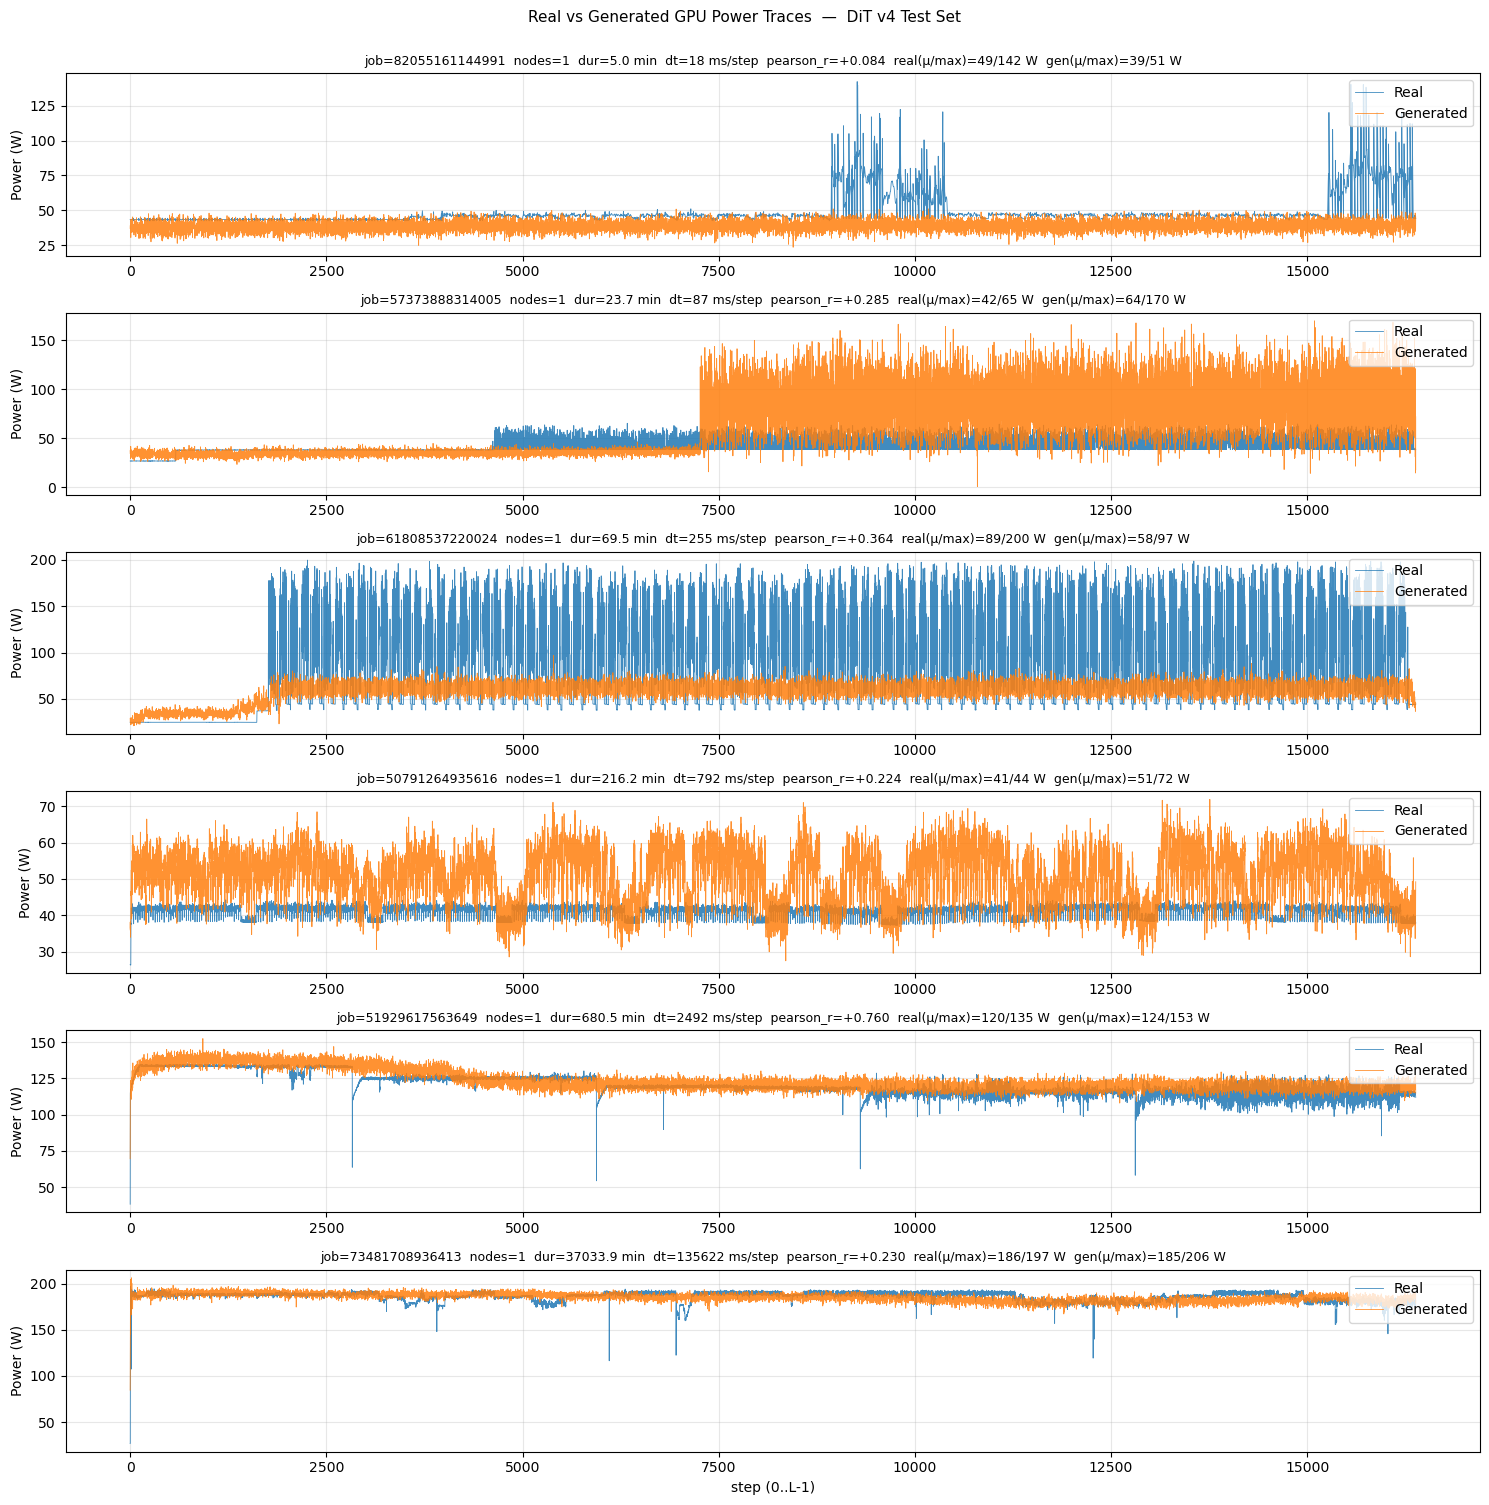

Saved → mit/model_v4/test_trace_samples.png
Parallel watts resampling with 126 workers (time_start=False)...
  1,000  (2/s)
  2,000  (5/s)
  3,000  (7/s)
  4,000  (10/s)
  5,000  (12/s)
  6,000  (15/s)
  7,000  (17/s)
  8,000  (20/s)
  9,000  (22/s)
Wrote 9,817 parquets in 6.9 min → mit/dataset/test-synthethic-v4-watts


In [25]:
# ── Reload best EMA checkpoint for inference ─────────────────────────────────
ckpt = torch.load(CFG["save_path"], map_location=device, weights_only=False)
print(f"Loading best model from epoch {ckpt['epoch']}, val_loss={ckpt['val_loss']:.4f}")

eval_net = DiT1D_v4(CFG).to(device)
state    = {k.replace("_orig_mod.", ""): v for k, v in ckpt["model"].items()}
eval_net.load_state_dict(state, strict=True)
# Overwrite student weights with EMA (what produced best val loss)
ema_state = {k.replace("_orig_mod.", ""): v for k, v in ckpt["ema"].items()}
with torch.no_grad():
    for n, p in eval_net.named_parameters():
        if n in ema_state:
            p.data.copy_(ema_state[n].to(p.device))

# ── Bulk DDIM inference on test set (writes one .npy per job_id) ─────────────
UNCOMMENT this block to (re)generate the .npy files in TEST_SYNTH_DIR.
Skip it if you already have them on disk from a prior run.
ddim_sample_dataset_v(eval_net, schedule, test_ds, CFG, device,
                       save_dir=TEST_SYNTH_DIR, batch_size=128,
                       cfg_scale=CFG["cfg_scale"], amp_dtype=amp_dtype)

# ── Compute metrics from saved .npy files (no re-sampling) ───────────────────
results_df = evaluate_from_disk(TEST_SYNTH_DIR, test_ds, CFG)

# ── Plot a handful of real-vs-generated traces from saved .npy ───────────────
plot_samples_from_disk(TEST_SYNTH_DIR, test_ds, CFG, n_samples=6)

# ── Resample generated outputs to 100ms grid + denormalize to watts ──────────
materialize_watts_outputs(TEST_SYNTH_DIR, TEST_SYNTH_WATTS, test_ds)
